## Import Dependencies

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras import layers, models, callbacks
import json

2025-06-12 13:34:06.184416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749735246.377914      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749735246.434489      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Set Paths and Basic Config

In [2]:
DATA_DIR = '/kaggle/input/plantdisease/PlantVillage'
IMG_SIZE = (240, 240)
BATCH_SIZE = 32
SEED = 42

## Create Train/Validation Split
 We will use ImageDataGenerator for a stratified split using the folder structure.

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

valid_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

NUM_CLASSES = train_generator.num_classes

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [4]:
# Save class mapping
class_indices = train_generator.class_indices
print(class_indices)

with open('/kaggle/working/class_names.json', 'w') as f:
    json.dump(list(class_indices.keys()), f)

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


## Build the Model

In [5]:
base_model = EfficientNetB1(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1749735266.405184      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749735266.405889      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Add Callbacks

In [6]:
checkpoint_cb = callbacks.ModelCheckpoint(
    '/kaggle/working/efficientnetb1_plant.weights.h5',  # ✅ Save weights only
    save_best_only=True,
    save_weights_only=True,
    monitor='val_accuracy'
)
earlystop_cb = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

## Train the Model

In [7]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[checkpoint_cb, earlystop_cb]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1749735291.668507      75 service.cc:148] XLA service 0x788c80002de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749735291.669410      75 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749735291.669431      75 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749735294.239823      75 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/517 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - accuracy: 0.0078 - loss: 2.7675       

I0000 00:00:1749735308.021335      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


517/517 ━━━━━━━━━━━━━━━━━━━━ 434s 769ms/step - accuracy: 0.1326 - loss: 2.6141 - val_accuracy: 0.1555 - val_loss: 2.5789
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 266s 513ms/step - accuracy: 0.1475 - loss: 2.5929 - val_accuracy: 0.0859 - val_loss: 2.5865
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 273s 528ms/step - accuracy: 0.1461 - loss: 2.5929 - val_accuracy: 0.1555 - val_loss: 2.5812
Epoch 4/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 277s 535ms/step - accuracy: 0.1406 - loss: 2.5906 - val_accuracy: 0.1555 - val_loss: 2.5684
Epoch 5/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 273s 529ms/step - accuracy: 0.1369 - loss: 2.5951 - val_accuracy: 0.1555 - val_loss: 2.5985
Epoch 6/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 275s 532ms/step - accuracy: 0.1431 - loss: 2.5966 - val_accuracy: 0.1555 - val_loss: 2.5730


## Plot Training History

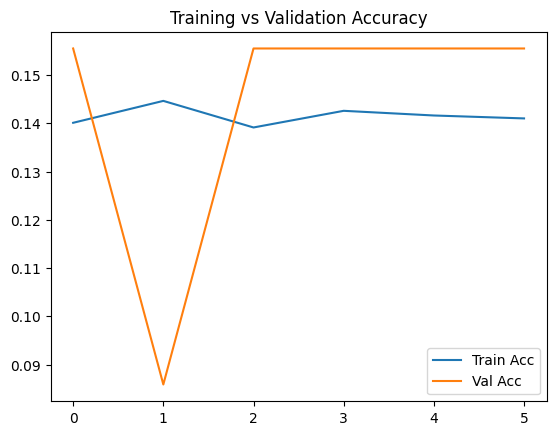

In [8]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [9]:
# Saving initial weights just for inspection and size comparison
model.save_weights('/kaggle/working/efficientnetb1_Init.weights.h5')

## Fine-Tuning Phase (Unfreeze Base & Retrain)

In [10]:
# Unfreeze the entire base model
base_model.trainable = True

# Optionally, freeze the first few layers if needed (e.g., for stability)
# for layer in base_model.layers[:200]:
#     layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Continue Fine-Tuning

In [11]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,  # Add more if needed
    callbacks=[checkpoint_cb, earlystop_cb]
)

Epoch 1/10


E0000 00:00:1749737162.128204      77 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749737162.273269      77 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749737162.757967      77 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749737162.899250      77 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749737163.040595      77 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

  2/517 ━━━━━━━━━━━━━━━━━━━━ 1:47 208ms/step - accuracy: 0.0547 - loss: 2.9782   

E0000 00:00:1749737204.614258      77 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749737204.749388      77 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


517/517 ━━━━━━━━━━━━━━━━━━━━ 476s 691ms/step - accuracy: 0.1599 - loss: 2.6282 - val_accuracy: 0.2445 - val_loss: 2.4262
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 297s 574ms/step - accuracy: 0.6968 - loss: 1.2815 - val_accuracy: 0.8297 - val_loss: 0.6555
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 302s 583ms/step - accuracy: 0.8320 - loss: 0.6613 - val_accuracy: 0.8942 - val_loss: 0.3894
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 299s 578ms/step - accuracy: 0.8855 - loss: 0.4220 - val_accuracy: 0.9131 - val_loss: 0.2936
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 290s 560ms/step - accuracy: 0.9151 - loss: 0.3089 - val_accuracy: 0.8998 - val_loss: 0.3320
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 292s 564ms/step - accuracy: 0.9298 - loss: 0.2417 - val_accuracy: 0.9425 - val_loss: 0.1867
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 287s 554ms/step - accuracy: 0.9481 - loss: 0.1867 - val_accuracy: 0.9299 - val_loss: 0.2128
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 289s 558ms/step - accuracy: 0.9528 - loss: 0.15

## Save Fine-Tuned Model

In [12]:
# Save final weights after fine-tuning
model.save_weights('/kaggle/working/efficientnetb1_plant_final.weights.h5')